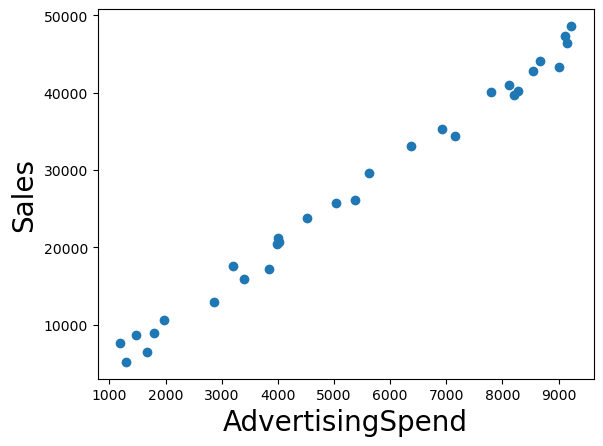

Weight of the model=[[4.96358355]]
Intercept of the model=[424.70662617]


In [7]:
# import pandas library to handle dataset and store it inside pd variable 
import pandas as pd
# import matplotlib library used for creating graphs.and module pyplot used for plotting dataset and store it inside plt variable 
import matplotlib.pyplot as plt

# Read the csv file sales_data and store it in variable data
data = pd.read_csv('sales_data.csv')

#Indepedent Variable,AdvertisingSpend, datatype float
independent = data[["AdvertisingSpend"]] 
# Depedent Variable, Sales, datatype float
dependent = data[["Sales"]] 

# Below 4 lines are used for plotting the dataset
plt.scatter(independent,dependent)
plt.xlabel('AdvertisingSpend',fontsize=20)
plt.ylabel('Sales',fontsize=20)
plt.show()

# From sklearn.model_selection file import module train_test_split 
#(Used for  building and evaluating machine‑learning models)
from sklearn.model_selection import train_test_split

#Splits dataset into train and test
#X_train = input_train(Contains AdvertisingSpend train data), X_test = input_test(Contains AdvertisingSpend test data)
#y_train = output_train(Contains Sales train data), y_test = output_test(Contains Sales test data)
#test_size = 1/3 (splits the 1/3rd data for test data)
X_train, X_test, y_train, y_test = train_test_split(independent,dependent, test_size = 1/3, random_state = 0)

# Creating & training the model
# From sklearn.linear_model file import module LinearRegression 
from sklearn.linear_model import LinearRegression

# regressor variable is used to store the functions of LinearRegression
regressor = LinearRegression()

# Used to calculate weight and bais based on the formula y=W*x1+b0 for this equation we got value for b1 and bo
regressor.fit(X_train, y_train)

# Viewing the b1 and bo value
weight=regressor.coef_
print("Weight of the model={}".format(weight))
bais=regressor.intercept_
print("Intercept of the model={}".format(bais))

##Model ready for prediction
# Using the test dataset X_test to prediction and storing it in variable y_pred
y_pred=regressor.predict(X_test)

# From sklearn.metrics file import module r2_score (Uses R2 as Evaluation method for validating the prediction) 
from sklearn.metrics import r2_score

# Identifies the r2 score by passing the dataset y_test and y_pred and storing it in variable r_score
r_score=r2_score(y_test,y_pred)

# Print r_score Used to identify the Rscore (Note- r_score Near to 1 , the model works efficiently) 
r_score

#since the r_score value is closed to 1, Save the model
# Below line is used for Saving machine‑learning models
import pickle 

# Save the model with filename final_sales_prediction_model
filename = 'final_sales_prediction_model.sav'

#Opens the file and writes the data
pickle.dump(regressor, open(filename, 'wb'))
